
📐 MATHEMATICAL STEP-BY-STEP BREAKDOWN FOR TRAINING VIA ID3

[Depth 0 Branch Context: Root Selection]
   • Data Subset Size: 14 rows | Class Distribution: {'No': 5, 'Yes': 9}
   • Current Parent Entropy: 0.9403
   📊 Feature: 'Age'
    - Branch 'M': 4 rows, Entropy = -0.0000
    - Branch 'S': 5 rows, Entropy = 0.9710
    - Branch 'Y': 5 rows, Entropy = 0.9710
    ➔ Weighted Children Impurity: 0.6935 | Total Info Gain: 0.2467
   📊 Feature: 'Student'
    - Branch 'No': 7 rows, Entropy = 0.9852
    - Branch 'Yes': 7 rows, Entropy = 0.5917
    ➔ Weighted Children Impurity: 0.7885 | Total Info Gain: 0.1518
   📊 Feature: 'Credit_rating'
    - Branch 'Excellent': 6 rows, Entropy = 1.0000
    - Branch 'Fair': 8 rows, Entropy = 0.8113
    ➔ Weighted Children Impurity: 0.8922 | Total Info Gain: 0.0481
   📊 Feature: 'Income'
    - Branch 'High': 4 rows, Entropy = 1.0000
    - Branch 'Low': 4 rows, Entropy = 0.8113
    - Branch 'Medium': 6 rows, Entropy = 0.9183
    ➔ Weighted Children Impurity: 0.

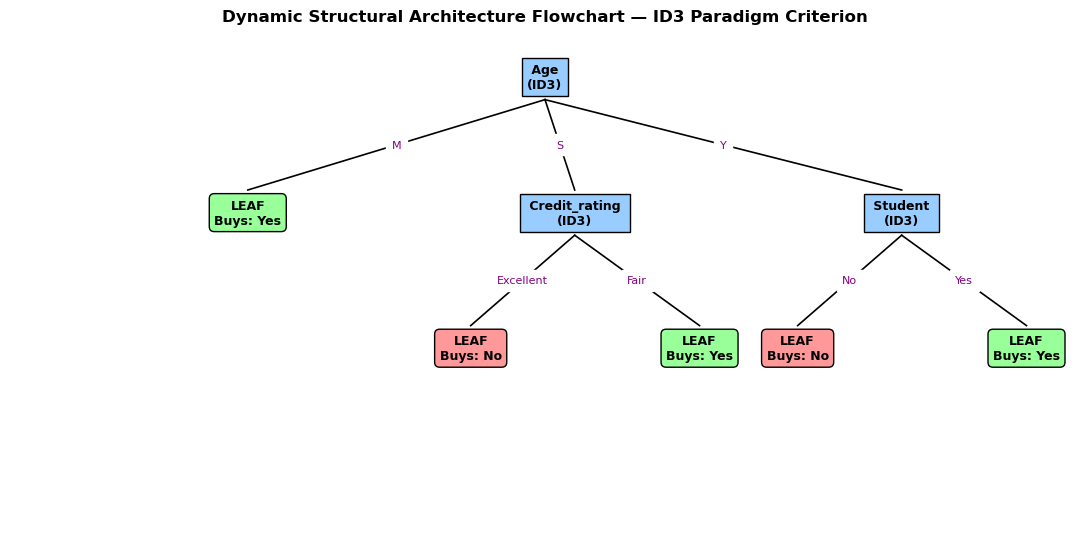


📐 MATHEMATICAL STEP-BY-STEP BREAKDOWN FOR TRAINING VIA C4.5

[Depth 0 Branch Context: Root Selection]
   • Data Subset Size: 14 rows | Class Distribution: {'No': 5, 'Yes': 9}
   • Current Parent Entropy: 0.9403
   📊 Feature: 'Age'
    - Branch 'M': 4 rows, Entropy = -0.0000
    - Branch 'S': 5 rows, Entropy = 0.9710
    - Branch 'Y': 5 rows, Entropy = 0.9710
    ➔ SplitInfo: 1.5774 | Total Gain Ratio: 0.1564
   📊 Feature: 'Student'
    - Branch 'No': 7 rows, Entropy = 0.9852
    - Branch 'Yes': 7 rows, Entropy = 0.5917
    ➔ SplitInfo: 1.0000 | Total Gain Ratio: 0.1518
   📊 Feature: 'Credit_rating'
    - Branch 'Excellent': 6 rows, Entropy = 1.0000
    - Branch 'Fair': 8 rows, Entropy = 0.8113
    ➔ SplitInfo: 0.9852 | Total Gain Ratio: 0.0488
   📊 Feature: 'Income'
    - Branch 'High': 4 rows, Entropy = 1.0000
    - Branch 'Low': 4 rows, Entropy = 0.8113
    - Branch 'Medium': 6 rows, Entropy = 0.9183
    ➔ SplitInfo: 1.5567 | Total Gain Ratio: 0.0188
   🏆 Winner: Picked **'Age'** as

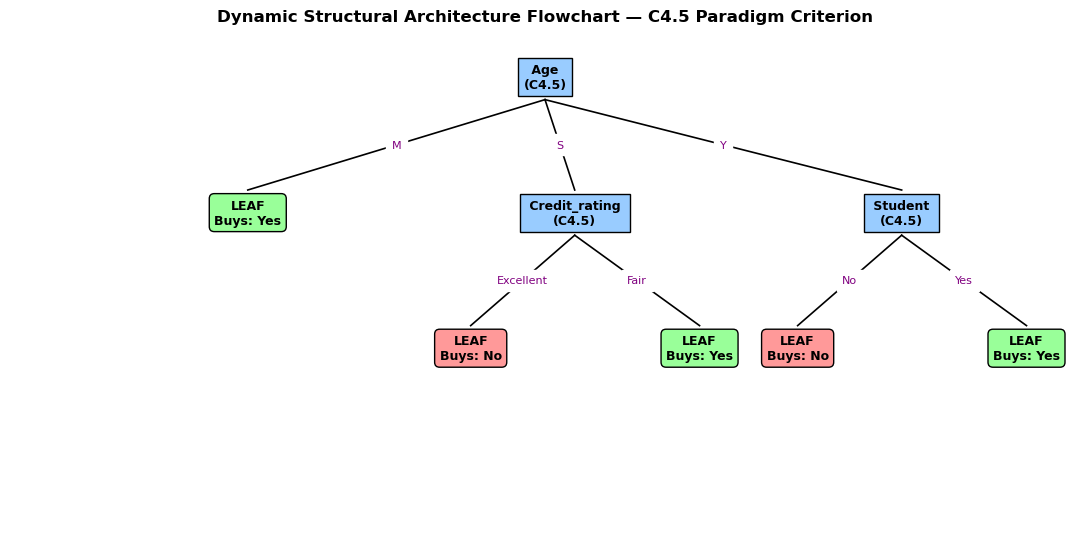


📐 MATHEMATICAL STEP-BY-STEP BREAKDOWN FOR TRAINING VIA CART

[Depth 0 Branch Context: Root Selection]
   • Data Subset Size: 14 rows | Class Distribution: {'No': 5, 'Yes': 9}
   • Current Parent Gini Impurity: 0.4592
   📊 Feature: 'Age'
    - Branch 'M': 4 rows, Gini Impurity = 0.0000
    - Branch 'S': 5 rows, Gini Impurity = 0.4800
    - Branch 'Y': 5 rows, Gini Impurity = 0.4800
    ➔ Weighted Children Impurity: 0.3429 | Total Gini Gain: 0.1163
   📊 Feature: 'Student'
    - Branch 'No': 7 rows, Gini Impurity = 0.4898
    - Branch 'Yes': 7 rows, Gini Impurity = 0.2449
    ➔ Weighted Children Impurity: 0.3673 | Total Gini Gain: 0.0918
   📊 Feature: 'Credit_rating'
    - Branch 'Excellent': 6 rows, Gini Impurity = 0.5000
    - Branch 'Fair': 8 rows, Gini Impurity = 0.3750
    ➔ Weighted Children Impurity: 0.4286 | Total Gini Gain: 0.0306
   📊 Feature: 'Income'
    - Branch 'High': 4 rows, Gini Impurity = 0.5000
    - Branch 'Low': 4 rows, Gini Impurity = 0.3750
    - Branch 'Medium': 6

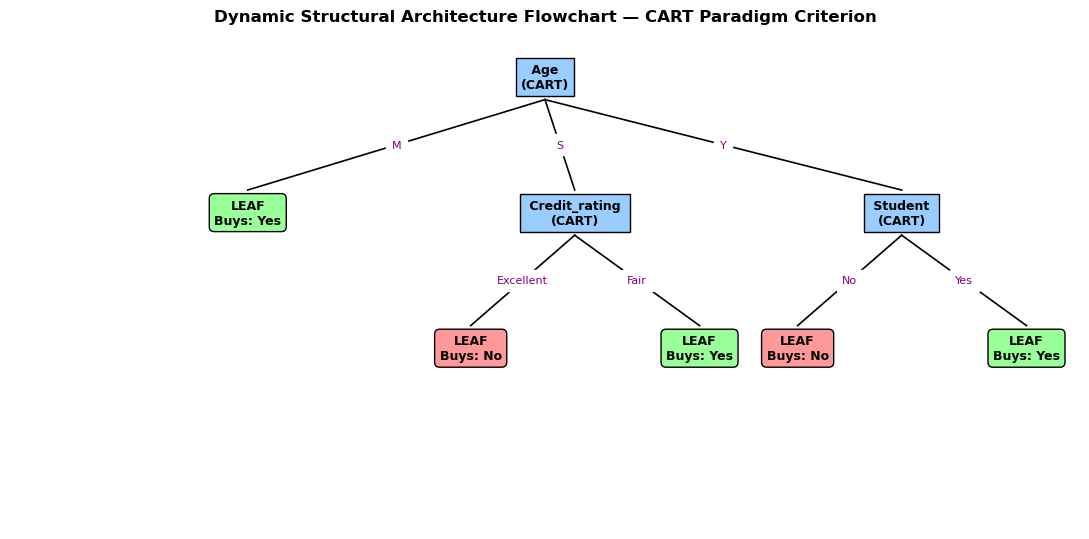

In [3]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# ==========================================
# 1. Categorical Multi-Way Tree Components
# ==========================================
class MultiWayNode:
    def __init__(self, feature_name=None, gain=None, algorithm_used=None, children=None, value=None):
        self.feature_name = feature_name  # Feature column string name
        self.gain = gain                  # Best score achieved
        self.algorithm_used = algorithm_used
        self.children = children          # Dictionary: {feature_value: MultiWayNode}
        self.value = value                # Leaf prediction target label (e.g., 'Yes' or 'No')

class CategoricalDecisionTree:
    def __init__(self, algorithm='ID3', max_depth=5):
        self.algorithm = algorithm  # 'ID3' (Entropy), 'C4.5' (Gain Ratio), or 'CART' (Gini)
        self.max_depth = max_depth
        self.root = None

    def fit(self, df, feature_columns, target_column):
        print("\n" + "="*80)
        print(f"📐 MATHEMATICAL STEP-BY-STEP BREAKDOWN FOR TRAINING VIA {self.algorithm}")
        print("="*80)
        self.root = self._build_tree(df, feature_columns, target_column, curr_depth=0, path_taken="Root Selection")

    def _calculate_impurity(self, y):
        if len(y) == 0: 
            return 0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        
        if self.algorithm in ['ID3', 'C4.5']:
            # Entropy = - \sum p_i \log_2(p_i)
            return -np.sum(probs * np.log2(probs + 1e-9))
        elif self.algorithm == 'CART':
            # Gini Impurity = 1 - \sum (p_i)^2
            return 1.0 - np.sum(probs ** 2)

    def _build_tree(self, df, features, target, curr_depth, path_taken):
        y = df[target].values
        
        # Base Case 1: Pure Node
        if len(np.unique(y)) == 1:
            return MultiWayNode(value=y[0])
            
        # Base Case 2: Out of features or depth limit hit
        if len(features) == 0 or curr_depth >= self.max_depth:
            majority_val = Counter(y).most_common(1)[0][0]
            return MultiWayNode(value=majority_val)

        # Print current branch node status info
        print(f"\n[Depth {curr_depth} Branch Context: {path_taken}]")
        parent_impurity = self._calculate_impurity(y)
        impurity_name = "Entropy" if self.algorithm in ['ID3', 'C4.5'] else "Gini Impurity"
        
        counts_dict = Counter(y)
        print(f"   • Data Subset Size: {len(y)} rows | Class Distribution: {dict(counts_dict)}")
        print(f"   • Current Parent {impurity_name}: {parent_impurity:.4f}")

        best_feature = None
        max_gain = -float('inf')
        math_logs = []

        # Evaluate every remaining feature choice item
        for feature in features:
            weighted_impurity = 0
            group_details = []
            split_info = 0
            
            for val, group in df.groupby(feature):
                g_y = group[target].values
                weight = len(group) / len(df)
                g_impurity = self._calculate_impurity(g_y)
                weighted_impurity += weight * g_impurity
                
                # Split info calculation for C4.5
                p = len(group) / len(df)
                split_info -= p * np.log2(p + 1e-9)
                
                group_details.append(f"    - Branch '{val}': {len(g_y)} rows, {impurity_name} = {g_impurity:.4f}")

            # Basic Gain (Information Gain or Gini Gain)
            gain = parent_impurity - weighted_impurity
            metric_label = "Info Gain" if self.algorithm == 'ID3' else "Gini Gain"

            if self.algorithm == 'C4.5':
                # Gain Ratio = Information Gain / Split Information
                gain = gain / (split_info + 1e-9)
                metric_label = "Gain Ratio"

            log_str = f"   📊 Feature: '{feature}'\n" + "\n".join(group_details) + "\n"
            if self.algorithm == 'C4.5':
                log_str += f"    ➔ SplitInfo: {split_info:.4f} | Total {metric_label}: {gain:.4f}"
            else:
                log_str += f"    ➔ Weighted Children Impurity: {weighted_impurity:.4f} | Total {metric_label}: {gain:.4f}"
            
            math_logs.append((gain, log_str, feature))

        # Sort logs to print out cleanly and locate the maximum metric choice item
        math_logs.sort(key=lambda x: x[0], reverse=True)
        for _, log, _ in math_logs:
            print(log)

        best_feature = math_logs[0][2]
        max_gain = math_logs[0][0]

        print(f"   🏆 Winner: Picked **'{best_feature}'** as split criteria node (Highest Score = {max_gain:.4f})")

        if max_gain <= 0:
            return MultiWayNode(value=Counter(y).most_common(1)[0][0])

        # Recursively branch out multi-way mapping
        children = {}
        remaining_features = [f for f in features if f != best_feature]
        
        for val, group in df.groupby(best_feature):
            children[val] = self._build_tree(group, remaining_features, target, curr_depth + 1, f"{best_feature} -> {val}")

        return MultiWayNode(feature_name=best_feature, gain=max_gain, algorithm_used=self.algorithm, children=children)

    def print_tree(self, node=None, indent=""):
        if node is None:
            node = self.root
        if node.value is not None:
            print(f" ➔ Predict: [ {node.value} ]")
            return
        
        print(f"\n{indent}❓ Node Check: [ {node.feature_name} ] (Metric: {node.gain:.4f})")
        for val, child_node in node.children.items():
            print(f"{indent}  └── Value Selected [ {val} ]", end="")
            self.print_tree(child_node, indent + "      ")


# ==========================================
# 2. Graphic Visualization Module Layout
# ==========================================
def plot_multi_tree(node, x, y, dx, dy):
    if node.value is not None:
        color = "#ff9999" if node.value == "No" else "#99ff99"
        plt.text(x, y, f"LEAF\nBuys: {node.value}", 
                 bbox=dict(boxstyle="round,pad=0.4", fc=color, ec="black"),
                 ha="center", va="center", fontsize=9, fontweight='bold')
        return

    plt.text(x, y, f" {node.feature_name} \n({node.algorithm_used})", 
             bbox=dict(boxstyle="square,pad=0.4", fc="#99ccff", ec="black"),
             ha="center", va="center", fontsize=9, fontweight='bold')

    num_children = len(node.children)
    step = dx * 2.2 / max(1, (num_children - 1)) if num_children > 1 else dx
    start_x = x - dx if num_children > 1 else x

    for i, (branch_val, child_node) in enumerate(node.children.items()):
        child_x = start_x + (i * step)
        child_y = y - dy
        
        plt.plot([x, child_x], [y - 0.04, child_y + 0.04], color="black", lw=1.2)
        plt.text((x + child_x)/2, (y + child_y)/2, str(branch_val), 
                 fontsize=8, color="purple", backgroundcolor="white", ha="center", va="center")
        
        plot_multi_tree(child_node, child_x, child_y, dx * 0.35, dy)


# ==========================================
# 3. Execution Execution Blueprint
# ==========================================
if __name__ == "__main__":
    # Reading your dataset directly
    df = pd.read_csv('Buys_Computer_Dataset.csv')

    features = ["Age", "Income", "Student", "Credit_rating"]
    target = "class:buys_comp"

    # Iterate through all standard classical tree algorithm criteria models
    all_algorithms = ['ID3', 'C4.5', 'CART']
    
    for algo_type in all_algorithms:
        tree = CategoricalDecisionTree(algorithm=algo_type, max_depth=4)
        tree.fit(df, features, target)

        print("\n" + "="*80)
        print(f"🌳 FINAL PRINT-TREE SCHEMATIC DIAGRAM MAP FOR: {algo_type}")
        print("="*80)
        tree.print_tree()
        print("\n" + "="*80 + "\n")

        # Create Matplotlib Tree Canvas
        plt.figure(figsize=(11, 5.5))
        plt.axis('off')
        plt.title(f"Dynamic Structural Architecture Flowchart — {algo_type} Paradigm Criterion", 
                  fontsize=12, pad=20, fontweight='bold')
        
        plot_multi_tree(tree.root, x=0.5, y=1.0, dx=0.25, dy=0.24)
        
        plt.xlim(0.05, 0.95)
        plt.ylim(0.2, 1.05)
        plt.tight_layout()
        plt.show()


In [2]:
import numpy as np
import pandas as pd
from collections import defaultdict

class CategoricalNaiveBayes:
    def __init__(self, alpha=1.0):
        self.alpha = alpha  # Laplace smoothing factor
        self.prior_probabilities = {}
        self.conditional_probabilities = defaultdict(lambda: defaultdict(dict))
        self.classes = []
        self.features = []

    def fit(self, df, feature_columns, target_column):
        self.features = feature_columns
        self.classes = df[target_column].unique()
        total_samples = len(df)

        print("\n" + "="*80)
        print("📐 NAIVE BAYES MATHEMATICAL TRAINING STEP-BY-STEP BREAKDOWN")
        print("="*80)

        # 1. Calculate Prior Probabilities P(C_i)
        print("\n[Step 1: Prior Probabilities of Classes P(C)]")
        for c in self.classes:
            class_count = len(df[df[target_column] == c])
            self.prior_probabilities[c] = class_count / total_samples
            print(f"  • P(class = '{c}') = {class_count} / {total_samples} = {self.prior_probabilities[c]:.4f}")

        # 2. Calculate Conditional Probabilities P(X_j | C_i) with Laplace Smoothing
        print("\n[Step 2: Conditional Probabilities P(Feature = Value | Class)]")
        for feature in self.features:
            unique_values = df[feature].unique()
            num_unique_values = len(unique_values)
            print(f"\n  📊 Feature Column: '{feature}'")
            
            for c in self.classes:
                class_df = df[df[target_column] == c]
                total_class_count = len(class_df)
                
                for val in unique_values:
                    matching_count = len(class_df[class_df[feature] == val])
                    
                    # Apply Laplace Smoothing: (Count + alpha) / (Total Class Count + alpha * Number of Unique Values)
                    smoothed_prob = (matching_count + self.alpha) / (total_class_count + self.alpha * num_unique_values)
                    self.conditional_probabilities[feature][c][val] = smoothed_prob
                    
                    print(f"    - P({feature}='{val}' | class='{c}') = ({matching_count} + {self.alpha}) / ({total_class_count} + {self.alpha}*{num_unique_values}) = {smoothed_prob:.4f}")

    def predict_single(self, sample_dict):
        """Calculates posterior probabilities for a single test sample dictionary"""
        posteriors = {}
        math_steps = []

        for c in self.classes:
            # Start with the log prior to avoid underflow, or pure multiplication for textbook demonstration
            probability = self.prior_probabilities[c]
            calculation_str = f"{probability:.4f}"
            
            for feature, val in sample_dict.items():
                if feature in self.features:
                    # If an unseen value appears during testing, fallback to smoothing baseline
                    cond_prob = self.conditional_probabilities[feature][c].get(val, 1 / (len(self.conditional_probabilities[feature][c]) + 1e-9))
                    probability *= cond_prob
                    calculation_str += f" * {cond_prob:.4f}"
            
            posteriors[c] = probability
            math_steps.append(f"  • P(Class='{c}' | X) ∝ {calculation_str} = {probability:.6f}")
            
        # Return winning class, raw score map, and math log lines
        winning_class = max(posteriors, key=posteriors.get)
        return winning_class, posteriors, math_steps


# ==========================================
# Execution Main Program
# ==========================================
if __name__ == "__main__":
    # Load dataset from the file
    df = pd.read_csv('Buys_Computer_Dataset.csv')

    features = ["Age", "Income", "Student", "Credit_rating"]
    target = "class:buys_comp"

    # Initialize and train the classifier
    nb_classifier = CategoricalNaiveBayes(alpha=1.0) # alpha=1.0 utilizes standard Laplace smoothing
    nb_classifier.fit(df, features, target)

    print("\n" + "="*80)
    print("🔮 PREDICTING A NEW TEST SAMPLE EXAMPLE")
    print("="*80)

    # Define a test sample matching a typical exam question problem:
    # "Predict if a person who is Youth, has Medium income, is a Student, and has a Fair credit rating will buy a computer"
    test_sample = {
        "Age": "Y",
        "Income": "Medium",
        "Student": "Yes",
        "Credit_rating": "Fair"
    }

    print(f"Target Test Sample features: {test_sample}")
    prediction, scores, steps = nb_classifier.predict_single(test_sample)
    
    print("\nPosterior Multiplication Steps:")
    for step in steps:
        print(step)
        
    print(f"\n🏆 Final Classification Decision Result: ** {prediction} **")
    print("="*80 + "\n")


📐 NAIVE BAYES MATHEMATICAL TRAINING STEP-BY-STEP BREAKDOWN

[Step 1: Prior Probabilities of Classes P(C)]
  • P(class = 'No') = 5 / 14 = 0.3571
  • P(class = 'Yes') = 9 / 14 = 0.6429

[Step 2: Conditional Probabilities P(Feature = Value | Class)]

  📊 Feature Column: 'Age'
    - P(Age='Y' | class='No') = (3 + 1.0) / (5 + 1.0*3) = 0.5000
    - P(Age='M' | class='No') = (0 + 1.0) / (5 + 1.0*3) = 0.1250
    - P(Age='S' | class='No') = (2 + 1.0) / (5 + 1.0*3) = 0.3750
    - P(Age='Y' | class='Yes') = (2 + 1.0) / (9 + 1.0*3) = 0.2500
    - P(Age='M' | class='Yes') = (4 + 1.0) / (9 + 1.0*3) = 0.4167
    - P(Age='S' | class='Yes') = (3 + 1.0) / (9 + 1.0*3) = 0.3333

  📊 Feature Column: 'Income'
    - P(Income='High' | class='No') = (2 + 1.0) / (5 + 1.0*3) = 0.3750
    - P(Income='Medium' | class='No') = (2 + 1.0) / (5 + 1.0*3) = 0.3750
    - P(Income='Low' | class='No') = (1 + 1.0) / (5 + 1.0*3) = 0.2500
    - P(Income='High' | class='Yes') = (2 + 1.0) / (9 + 1.0*3) = 0.2500
    - P(Income='


📐 MARKOV CHAIN STEP-BY-STEP TRANSITION SEQUENCE ANALYSIS
Full Sequential Chain Path: No ➔ No ➔ Yes ➔ Yes ➔ Yes ➔ No ➔ Yes ➔ No ➔ Yes ➔ Yes ➔ Yes ➔ Yes ➔ Yes ➔ No

[Step 1: Counting Observed Transitions]
  • Transition 01: Current customer 'No' ➔ Next customer 'No'
  • Transition 02: Current customer 'No' ➔ Next customer 'Yes'
  • Transition 03: Current customer 'Yes' ➔ Next customer 'Yes'
  • Transition 04: Current customer 'Yes' ➔ Next customer 'Yes'
  • Transition 05: Current customer 'Yes' ➔ Next customer 'No'
  • Transition 06: Current customer 'No' ➔ Next customer 'Yes'
  • Transition 07: Current customer 'Yes' ➔ Next customer 'No'
  • Transition 08: Current customer 'No' ➔ Next customer 'Yes'
  • Transition 09: Current customer 'Yes' ➔ Next customer 'Yes'
  • Transition 10: Current customer 'Yes' ➔ Next customer 'Yes'
  • Transition 11: Current customer 'Yes' ➔ Next customer 'Yes'
  • Transition 12: Current customer 'Yes' ➔ Next customer 'Yes'
  • Transition 13: Current customer

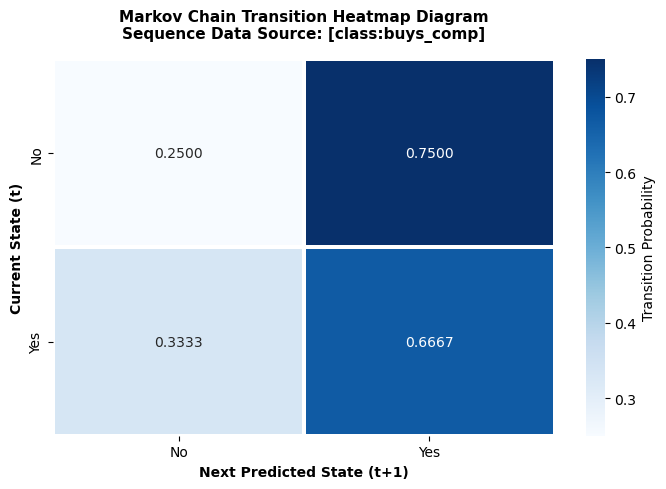

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class MarkovChainClassifier:
    def __init__(self):
        self.states = []
        self.transition_counts = {}
        self.transition_matrix = None
        self.state_to_idx = {}
        self.idx_to_state = {}

    def fit(self, df, sequence_column):
        # Extract the ordered sequence of events/decisions
        sequence = df[sequence_column].astype(str).tolist()
        self.states = sorted(list(set(sequence)))
        num_states = len(self.states)
        
        # Create map dictionaries between states and matrix indices
        self.state_to_idx = {state: idx for idx, state in enumerate(self.states)}
        self.idx_to_state = {idx: state for idx, state in enumerate(self.states)}
        
        # Initialize count matrix with zeros
        counts = np.zeros((num_states, num_states))
        
        print("\n" + "="*80)
        print("📐 MARKOV CHAIN STEP-BY-STEP TRANSITION SEQUENCE ANALYSIS")
        print("="*80)
        print(f"Full Sequential Chain Path: {' ➔ '.join(sequence)}\n")
        
        # 1. Count consecutive transitions: State(t) -> State(t+1)
        print("[Step 1: Counting Observed Transitions]")
        for i in range(len(sequence) - 1):
            current_state = sequence[i]
            next_state = sequence[i+1]
            
            row_idx = self.state_to_idx[current_state]
            col_idx = self.state_to_idx[next_state]
            
            counts[row_idx, col_idx] += 1
            print(f"  • Transition {i+1:02d}: Current customer '{current_state}' ➔ Next customer '{next_state}'")

        print("\nRaw Transition Counts Matrix Layout:")
        counts_df = pd.DataFrame(counts, index=self.states, columns=self.states)
        print(counts_df.to_string())

        # 2. Convert counts into row-normalized probabilities
        print("\n[Step 2: Normalizing to Probabilities (Row Sum = 1.0)]")
        self.transition_matrix = np.zeros((num_states, num_states))
        
        for i, state_from in enumerate(self.states):
            row_total = np.sum(counts[i, :])
            if row_total > 0:
                self.transition_matrix[i, :] = counts[i, :] / row_total
                print(f"  • Out of {int(row_total)} total states leaving '{state_from}':")
                for j, state_to in enumerate(self.states):
                    print(f"    - P({state_from} ➔ {state_to}) = {int(counts[i, j])} / {int(row_total)} = {self.transition_matrix[i, j]:.4f}")
            else:
                # Fallback uniform distribution if a state never transitions
                self.transition_matrix[i, :] = 1.0 / num_states

        self.transition_df = pd.DataFrame(self.transition_matrix, index=self.states, columns=self.states)

    def print_matrix(self):
        print("\n" + "="*80)
        print("📊 FINAL MARKOV TRANSITION PROBABILITY MATRIX")
        print("="*80)
        print(self.transition_df.to_string())
        print("="*80 + "\n")


# ==========================================
# Execution Main Program
# ==========================================
if __name__ == "__main__":
    # Load dataset from the file
    df = pd.read_csv('Buys_Computer_Dataset.csv')

    # The target dynamic sequence column
    sequence_col = "class:buys_comp"

    # Initialize and train the Markov Model
    markov_model = MarkovChainClassifier()
    markov_model.fit(df, sequence_col)
    markov_model.print_matrix()

    # Render empirical transition matrix heatmap visual representation
    plt.figure(figsize=(7, 5))
    sns.heatmap(markov_model.transition_df, annot=True, fmt=".4f", cmap="Blues", 
                linewidths=1.5, cbar_kws={'label': 'Transition Probability'})
    
    plt.title(f"Markov Chain Transition Heatmap Diagram\nSequence Data Source: [{sequence_col}]", 
              fontsize=11, pad=15, fontweight='bold')
    plt.ylabel("Current State (t)", fontsize=10, fontweight='bold')
    plt.xlabel("Next Predicted State (t+1)", fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [9]:
import numpy as np
import pandas as pd
from collections import defaultdict

class StandardNaiveBayes:
    def __init__(self):
        self.prior_probabilities = {}
        self.conditional_probabilities = defaultdict(lambda: defaultdict(dict))
        self.classes = []
        self.features = []

    def fit(self, df, feature_columns, target_column):
        self.features = feature_columns
        self.classes = df[target_column].unique()
        total_samples = len(df)

        print("\n" + "="*80)
        print(" STANDARD NAIVE BAYES MATH BREAKDOWN (NO LAPLACE SMOOTHING)")
        print("="*80)

        # 1. Calculate Prior Probabilities P(C_i)
        print("\n[Step 1: Prior Probabilities P(C)]")
        for c in self.classes:
            class_count = len(df[df[target_column] == c])
            self.prior_probabilities[c] = class_count / total_samples
            print(f"  • P(class = '{c}') = {class_count} / {total_samples} = {self.prior_probabilities[c]:.4f}")

        # 2. Calculate Raw Conditional Probabilities P(X_j | C_i)
        print("\n[Step 2: Raw Conditional Probabilities P(Feature = Value | Class)]")
        for feature in self.features:
            unique_values = df[feature].unique()
            print(f"\n   Feature Column: '{feature}'")
            
            for c in self.classes:
                class_df = df[df[target_column] == c]
                total_class_count = len(class_df)
                
                for val in unique_values:
                    matching_count = len(class_df[class_df[feature] == val])
                    
                    # RAW CALCULATION: No +1.0 in the numerator, no unique value multiplier in the denominator
                    raw_prob = matching_count / total_class_count
                    self.conditional_probabilities[feature][c][val] = raw_prob
                    
                    print(f"    - P({feature}='{val}' | class='{c}') = {matching_count} / {total_class_count} = {raw_prob:.4f}")

    def predict_single(self, sample_dict):
        """Calculates posterior probabilities using raw multiplications"""
        posteriors = {}
        math_steps = []

        for c in self.classes:
            probability = self.prior_probabilities[c]
            calculation_str = f"{probability:.4f}"
            
            for feature, val in sample_dict.items():
                if feature in self.features:
                    # Fetches raw probability; defaults to 0.0 if value is completely unseen in training
                    cond_prob = self.conditional_probabilities[feature][c].get(val, 0.0)
                    probability *= cond_prob
                    calculation_str += f" * {cond_prob:.4f}"
            
            posteriors[c] = probability
            math_steps.append(f"  • P(Class='{c}' | X) ∝ {calculation_str} = {probability:.6f}")
            
        winning_class = max(posteriors, key=posteriors.get)
        return winning_class, posteriors, math_steps


# ==========================================
# Execution Main Program
# ==========================================
if __name__ == "__main__":
    # Load dataset from the file
    df = pd.read_csv('Buys_Computer_Dataset.csv')

    features = ["Age", "Income", "Student", "Credit_rating"]
    target = "class:buys_comp"

    # Initialize and train the raw classifier
    nb_classifier = StandardNaiveBayes()
    nb_classifier.fit(df, features, target)

    print("\n" + "="*80)
    print("PREDICTING A NEW TEST SAMPLE (RAW CALCULATIONS)")
    print("="*80)

    # You can change the test samples here as needed:
    test_sample = {
        "Age": "Y",
        "Income": "Low",
        "Student": "Yes",
        "Credit_rating": "Fair"
    }

    print(f"Target Test Sample features: {test_sample}")
    prediction, scores, steps = nb_classifier.predict_single(test_sample)
    
    print("\nPosterior Multiplication Steps:")
    for step in steps:
        print(step)
        
    print(f"\n Final Classification Decision Result: ** {prediction} **")
    print("="*80 + "\n")


 STANDARD NAIVE BAYES MATH BREAKDOWN (NO LAPLACE SMOOTHING)

[Step 1: Prior Probabilities P(C)]
  • P(class = 'No') = 5 / 14 = 0.3571
  • P(class = 'Yes') = 9 / 14 = 0.6429

[Step 2: Raw Conditional Probabilities P(Feature = Value | Class)]

   Feature Column: 'Age'
    - P(Age='Y' | class='No') = 3 / 5 = 0.6000
    - P(Age='M' | class='No') = 0 / 5 = 0.0000
    - P(Age='S' | class='No') = 2 / 5 = 0.4000
    - P(Age='Y' | class='Yes') = 2 / 9 = 0.2222
    - P(Age='M' | class='Yes') = 4 / 9 = 0.4444
    - P(Age='S' | class='Yes') = 3 / 9 = 0.3333

   Feature Column: 'Income'
    - P(Income='High' | class='No') = 2 / 5 = 0.4000
    - P(Income='Medium' | class='No') = 2 / 5 = 0.4000
    - P(Income='Low' | class='No') = 1 / 5 = 0.2000
    - P(Income='High' | class='Yes') = 2 / 9 = 0.2222
    - P(Income='Medium' | class='Yes') = 4 / 9 = 0.4444
    - P(Income='Low' | class='Yes') = 3 / 9 = 0.3333

   Feature Column: 'Student'
    - P(Student='No' | class='No') = 4 / 5 = 0.8000
    - P(Stude